In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys
import os
os.environ["DEBUG_LOGGER"] = "True"
os.environ["NUMBA_NTHREADS"] = "16"

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from matplotlib.colors import Normalize

sys.path.insert(0,'/home/emaragliano/Work/Projects/Dottorato/ZeldovichReconstruction/')


# Test Prolong

Spiegazione dei Test

1. Test Campo Costante: Verifica che l'interpolazione non introduca artefatti. La media di 10 e 10 deve essere 10. Se questo fallisce, c'è un errore grave negli indici.

2. Test Gradiente: È il test più importante. Creiamo una "salita" (0, 10, 20...). La griglia fine deve creare gli "scalini" intermedi (5, 15, 25...). Questo conferma che la logica della media (val_z = (A+B)*0.5) funziona.

3. Test Coincidenza: Verifica la regola matematica fondamentale: Fine(2x,2y,2z)==Coarse(x,y,z). Se questo è vero, significa che la griglia è allineata correttamente e non "shiftata" (spostata) di mezzo pixel.

In [3]:
from zeldareco.displacement_solver.multigrid_lib import prolong_jit

In [4]:
# --- 2. WRAPPER DI TEST CORRETTO ---
def test_prolong_wrapper(coarse_grid_3d):
    """Prepara i dati e chiama la funzione JIT"""
    # CORREZIONE QUI:
    # NumPy (C-order) gestisce le dimensioni come (Axis0, Axis1, Axis2).
    # Nel nostro codice JIT, Axis0 è quello su cui parallelizziamo (X).
    # Quindi non dobbiamo invertire l'ordine.
    nx, ny, nz = coarse_grid_3d.shape 
    
    # Parametri per la funzione
    nmesh_dims = np.array([nx, ny, nz], dtype=np.int32)
    
    # Creiamo output vuoto (dimensioni doppie)
    # Calcoliamo la dimensione totale flat
    total_size = (nx * 2) * (ny * 2) * (nz * 2)
    fine_grid_flat = np.zeros(total_size, dtype=np.float64)
    
    coarse_grid_flat = coarse_grid_3d.ravel() # Appiattisce
    
    # Parametri di parallelizzazione fittizi
    # Assumiamo che localnmeshx copra tutta la dimensione X
    localnmeshx = nx * 2
    offsetx = 0
    
    # CHIAMATA ALLA FUNZIONE
    prolong_jit(coarse_grid_flat, fine_grid_flat, nmesh_dims, localnmeshx, offsetx)
    
    # Ritorniamo in 3D mantenendo l'ordine (Nx, Ny, Nz)
    return fine_grid_flat.reshape((nx*2, ny*2, nz*2))

In [5]:
# --- ESECUZIONE TEST ---

def run_tests():
    print("--- INIZIO TEST PROLONG JIT ---")

    # TEST A: Campo Costante
    # Se tutto è 10, tutto deve rimanere 10.
    c1 = np.full((4, 4, 4), 10.0)
    f1 = test_prolong_wrapper(c1)
    if np.allclose(f1, 10.0):
        print("[PASS] Test Campo Costante: OK")
    else:
        print("[FAIL] Test Campo Costante: I valori sono cambiati!")

    # TEST B: Gradiente Lineare (1D)
    # Creiamo una rampa 0, 10, 20, 30 lungo l'asse Z
    # L'output dovrebbe avere passi intermedi: 0, 5, 10, 15...
    nx, ny, nz = 4, 4, 4
    c2 = np.zeros((nx, ny, nz))
    for z in range(nz):
        c2[:, :, z] = z * 10.0 # Valori 0, 10, 20, 30
        
    f2 = test_prolong_wrapper(c2)
    
    # Controlliamo i valori lungo Z alla posizione (0,0)
    # Coarse Z=0 (val 0) -> Fine Z=0 (val 0)
    # Coarse Z=1 (val 10) -> Fine Z=2 (val 10)
    # Fine Z=1 dovrebbe essere (0+10)/2 = 5
    vals = f2[0, 0, :6] 
    expected = np.array([0., 5., 10., 15., 20., 25.])
    
    if np.allclose(vals, expected):
        print(f"[PASS] Test Gradiente Z: OK. Primi valori: {vals}")
    else:
        print(f"[FAIL] Test Gradiente Z. Ottenuto: {vals}, Atteso: {expected}")

    # TEST C: Verifica "Coincidenza" (Proprietà Geometrica)
    # I punti della griglia fine con indici PARI devono essere identici ai punti della griglia coarse
    c3 = np.random.rand(8, 8, 8)
    f3 = test_prolong_wrapper(c3)
    
    # Slicing numpy: [::2] prende un elemento ogni 2 (quelli pari)
    f3_extracted = f3[::2, ::2, ::2]
    
    if np.allclose(f3_extracted, c3):
        print("[PASS] Test Coincidenza Nodi: OK (I valori originali sono preservati nei nodi pari)")
    else:
        print("[FAIL] Test Coincidenza Nodi: I valori sui nodi originali sono stati modificati!")

In [6]:
run_tests()

--- INIZIO TEST PROLONG JIT ---
[FAIL] Test Campo Costante: I valori sono cambiati!
[FAIL] Test Gradiente Z. Ottenuto: [ 0.  5. 10.  5. 10. 15.], Atteso: [ 0.  5. 10. 15. 20. 25.]
[FAIL] Test Coincidenza Nodi: I valori sui nodi originali sono stati modificati!


1. Test di Anisotropia (Griglia Non-Cubica)
    Obiettivo: Verificare che l'algoritmo gestisca correttamente dimensioni diverse lungo gli assi X, Y e Z.Perché è importante: È comune introdurre bug scambiando accidentalmente gli indici (es. usare ny al posto di nx nei loop o nel calcolo degli strides).Metodologia:

    Si crea una griglia di input con dimensioni irregolari (es. 3×4×2).

    Si esegue la funzione prolong.

    Si verifica che la griglia di output abbia esattamente dimensioni doppie (6×8×4) e che l'esecuzione non generi errori di segmentazione (out of bounds).
2. Test del Principio del Massimo (Stabilità)
    Obiettivo: Verificare che l'interpolazione non crei "overshoot" o "undershoot" (valori fantasma non presenti nei dati originali). Principio Matematico: L'interpolazione trilineare è una media pesata convessa. Pertanto, il valore di qualsiasi punto interpolato deve essere compreso tra il minimo e il massimo dei valori dei suoi vicini. Metodologia:

    - Si riempie la griglia Coarse con valori casuali.
    - Si calcola la griglia Fine.
    - Si asserisce che:

    $$min(Output)≥min(Input)−ϵ$$
    $$max(Output)≤max(Input)+ϵ$$
3. Test di Periodicità (Onda Sinusoidale)
    Obiettivo: Verificare la correttezza delle condizioni al contorno periodiche (Wrapping). Perché è importante: Garantisce che l'algoritmo colleghi correttamente l'ultimo indice della griglia al primo senza introdurre discontinuità o artefatti (bug "off-by-one"). Metodologia:

    - Si genera un'onda sinusoidale perfetta lungo l'asse X sulla griglia Coarse: f(x)=sin(x).
    - Si esegue l'interpolazione.
    - Si misura la differenza (derivata discreta) tra l'ultimo punto e il primo punto della griglia Fine (il punto di "cucitura").

    Se la periodicità funziona, questa differenza deve essere dello stesso ordine di grandezza della differenza tra due punti interni adiacenti.

4. Test "Split & Stitch" (Simulazione MPI)
    Obiettivo: Simulare un ambiente parallelo per garantire che l'algoritmo sia deterministico indipendentemente da come vengono divisi i dati. Scenario: In una simulazione reale MPI, ogni processo possiede solo una fetta (chunk) della griglia globale. Metodologia:

    Reference: Si esegue prolong su un'unica griglia globale intera.
    Split: Si divide l'input in due metà (Chunk A e Chunk B).
    Process: Si esegue prolong separatamente sui due chunk, passando i corretti parametri offsetx e localnmeshx.
    Stitch: Si ricompongono i due output parziali in un'unica griglia.
    Verifica: La griglia ricomposta deve essere identica bit-per-bit (o entro allclose) alla griglia di riferimento.

In [7]:
def run_advanced_tests():
    print("\n--- INIZIO TEST AVANZATI ---")

    # 1. TEST NON-CUBICO
    # Griglia strana: X=3, Y=4, Z=2
    dims = (3, 4, 2) 
    c_nc = np.random.rand(*dims) # *dims spacchetta la tupla
    f_nc = test_prolong_wrapper(c_nc)
    
    expected_shape = (6, 8, 4)
    if f_nc.shape == expected_shape:
        print(f"[PASS] Test Non-Cubico: Shape corretta {f_nc.shape}")
    else:
        print(f"[FAIL] Test Non-Cubico: Shape errata. Ottenuto {f_nc.shape}, Atteso {expected_shape}")


    # 2. TEST MAXIMUM PRINCIPLE
    c_rand = np.random.rand(10, 10, 10)
    f_rand = test_prolong_wrapper(c_rand)
    
    # Tolleranza minima per errori floating point
    eps = 1e-14
    if f_rand.min() >= c_rand.min() - eps and f_rand.max() <= c_rand.max() + eps:
        print("[PASS] Test Maximum Principle: Valori entro il range input.")
    else:
        print(f"[FAIL] Test Maximum Principle: Valori fuori range!\n"
              f"In Min: {c_rand.min()}, Out Min: {f_rand.min()}\n"
              f"In Max: {c_rand.max()}, Out Max: {f_rand.max()}")


    # 3. TEST PERIODICITÀ (Onda Sinusoidale)
    nx, ny, nz = 16, 1, 1 # Testiamo solo lungo X
    x = np.linspace(0, 2*np.pi, nx, endpoint=False) # 0 .. 2pi esclusi
    c_sin = np.sin(x).reshape(nx, ny, nz)
    
    f_sin = test_prolong_wrapper(c_sin)
    
    # Controlliamo il punto di "cucitura" tra fine e inizio
    # L'ultimo punto fine e il primo punto fine dovrebbero essere vicini 
    # come gli altri punti adiacenti
    diff_boundary = abs(f_sin[-1,0,0] - f_sin[0,0,0])
    diff_internal = abs(f_sin[10,0,0] - f_sin[11,0,0]) # Un punto a caso in mezzo
    
    # Le differenze dovrebbero essere simili (stesso ordine di grandezza)
    # Se la boundary è rotta, diff_boundary sarà molto diversa o zero in modo errato
    if abs(diff_boundary - diff_internal) < 0.1: 
        print(f"[PASS] Test Periodicità X: Continuità al bordo OK. (Diff Bordo: {diff_boundary:.4f}, Diff Interna: {diff_internal:.4f})")
    else:
        print(f"[FAIL] Test Periodicità X: Discontinuità rilevata al bordo! (Diff Bordo: {diff_boundary:.4f}, Diff Interna: {diff_internal:.4f})")


    # 4. TEST SPLIT & STITCH (Simulazione MPI)
    # Creiamo un array grande (es. X=10)
    nx_glob = 10
    c_full = np.random.rand(nx_glob, 4, 4)
    nmesh_dims = np.array([nx_glob, 4, 4], dtype=np.int32)
    
    # Esecuzione "Monolitica" (Ground Truth)
    f_full_ref = test_prolong_wrapper(c_full)
    
    # Esecuzione "Splittata" (Simuliamo 2 processi)
    # Processo 1: Gestisce prima metà (X da 0 a 5)
    chunk1_len = 5
    c_chunk1 = c_full[0:5, :, :]
    f_chunk1_flat = np.zeros(chunk1_len * 2 * 4 * 2 * 4 * 2) # Output flat vuoto
    prolong_jit(c_full.ravel(), f_chunk1_flat, nmesh_dims, chunk1_len*2, 0) # offset 0
    
    # Processo 2: Gestisce seconda metà (X da 5 a 10)
    chunk2_len = 5
    c_chunk2 = c_full[5:10, :, :]
    f_chunk2_flat = np.zeros(chunk2_len * 2 * 4 * 2 * 4 * 2)
    # NOTA: Passiamo sempre c_full.ravel() perché nel codice reale MPI avremmo 
    # accesso alla memoria o gestiremo i dati ghost, ma qui simuliamo l'offset.
    # IMPORTANTE: offsetx deve essere in coordinate FINE. 
    # Se il chunk coarse inizia a 5, il chunk fine inizia a 10.
    offset_fine = 5 * 2 
    prolong_jit(c_full.ravel(), f_chunk2_flat, nmesh_dims, chunk2_len*2, offset_fine)
    
    # Ricostruzione
    f_reconstructed = np.concatenate((
        f_chunk1_flat.reshape(10, 8, 8),
        f_chunk2_flat.reshape(10, 8, 8)
    ), axis=0)
    
    if np.allclose(f_full_ref, f_reconstructed):
        print("[PASS] Test Split MPI: L'esecuzione a pezzi coincide con quella intera.")
    else:
        print("[FAIL] Test Split MPI: Errore nel calcolo degli offset!")


In [8]:
run_advanced_tests()


--- INIZIO TEST AVANZATI ---
[PASS] Test Non-Cubico: Shape corretta (6, 8, 4)
[FAIL] Test Maximum Principle: Valori fuori range!
In Min: 0.0007864909809406351, Out Min: 0.0
In Max: 0.9986972297761217, Out Max: 0.9874348959281589
[PASS] Test Periodicità X: Continuità al bordo OK. (Diff Bordo: 0.0000, Diff Interna: 0.0000)
[FAIL] Test Split MPI: Errore nel calcolo degli offset!


# Test Reduce

In [9]:
from zeldareco.displacement_solver.multigrid_lib import reduce_jit

In [10]:
def test_reduce_wrapper(fine_grid_3d):
    """Wrapper per testare reduce_jit con array 3D NumPy standard"""
    nx, ny, nz = fine_grid_3d.shape
    
    # Dimensioni output
    nx_c, ny_c, nz_c = nx // 2, ny // 2, nz // 2
    
    # Input Flat
    fine_flat = fine_grid_3d.ravel()
    
    # Output Flat
    coarse_flat = np.zeros(nx_c * ny_c * nz_c, dtype=np.float64)
    
    # Parametri
    nmesh_dims_fine = np.array([nx, ny, nz], dtype=np.int32)
    localnmeshx_c = nx_c
    offsetx_c = 0
    
    # Chiamata JIT
    reduce_jit(fine_flat, coarse_flat, nmesh_dims_fine, localnmeshx_c, offsetx_c)
    
    return coarse_flat.reshape(nx_c, ny_c, nz_c)

def run_reduce_tests():
    print("\n=== ESECUZIONE TEST REDUCE (Restrizione) ===")
    
    # 1. TEST COSTANTE (Conservazione della Media)
    # Se la griglia fine è tutta 1.0, la griglia coarse deve essere 1.0
    f1 = np.ones((8, 8, 8)) * 10.0
    c1 = test_reduce_wrapper(f1)
    
    if np.allclose(c1, 10.0):
        print("[PASS] Test Costante: Media preservata correttamente.")
    else:
        print(f"[FAIL] Test Costante: Valore atteso 10.0, ottenuto {c1.mean()}")

    # 2. TEST DELTA (Impulso singolo)
    # Un singolo 1.0 al centro della griglia fine.
    # Vediamo quanto contribuisce alla cella coarse corrispondente.
    nx, ny, nz = 8, 8, 8
    f2 = np.zeros((nx, ny, nz))
    # Mettiamo un 1.0 nel punto che corrisponde al centro esatto di una cella coarse (indici pari)
    f2[2, 2, 2] = 1.0 
    
    c2 = test_reduce_wrapper(f2)
    
    # La cella coarse corrispondente è (1, 1, 1)
    # Il peso per il centro (0,0,0) è 8.
    # Quindi il valore dovrebbe essere 1.0 * 8 / 64 = 0.125
    val_center = c2[1, 1, 1]
    if np.isclose(val_center, 0.125):
        print(f"[PASS] Test Delta Centro: Peso corretto (0.125).")
    else:
        print(f"[FAIL] Test Delta Centro: Ottenuto {val_center}, Atteso 0.125")

    # 3. TEST ANISOTROPIA & BOUNDARY
    # Griglia rettangolare: 4x8x4 -> Output 2x4x2
    # Riempiamo con un gradiente lungo Y
    f3 = np.zeros((4, 8, 4))
    for y in range(8):
        f3[:, y, :] = y # 0, 1, 2, 3...
        
    c3 = test_reduce_wrapper(f3)
    
    # Controllo dimensioni
    if c3.shape == (2, 4, 2):
        print("[PASS] Test Shape: Output corretto (2, 4, 2).")
    else:
        print(f"[FAIL] Test Shape: Ottenuto {c3.shape}")
        
    # Controllo valori
    # La cella coarse 0 copre fine Y=0, Y=1. Media pesata...
    # Grossolanamente dovrebbe essere vicino alla media aritmetica 0.5, 2.5, etc.
    # Ma reduce fa una media pesata sui vicini, quindi è uno smoothing.
    print(f"      Valori Y Coarse: {c3[0, :, 0]}")

if __name__ == "__main__":
    run_reduce_tests()


=== ESECUZIONE TEST REDUCE (Restrizione) ===
[PASS] Test Costante: Media preservata correttamente.
[PASS] Test Delta Centro: Peso corretto (0.125).
[PASS] Test Shape: Output corretto (2, 4, 2).
      Valori Y Coarse: [2. 2. 4. 6.]


# TEST JACOBI

In [11]:
from zeldareco.displacement_solver.multigrid_lib import jacobi_jit

In [12]:
def run_solver_steps(v, f, n_iter, boxsize, beta=0.0):
    """
    Helper che esegue N iterazioni di Jacobi.
    Versione aggiornata per la firma COMPLETA (con offsetx/localnmeshx).
    """
    # 1. Calcoliamo N dalla dimensione dell'array
    N = round(len(v)**(1/3)) 
    nmesh_dims = np.array([N, N, N], dtype=np.int32)
    
    # 2. Parametri per Single Node (Simuliamo di possedere tutta la griglia)
    localnmeshx = N  # Tutta la dimensione X è nostra
    offsetx = 0      # Partiamo dall'inizio
    
    # 3. Buffer
    jac_buffer = np.zeros_like(v)
    
    # 4. Parametri fisici
    boxcenter = boxsize / 2.0
    damping = 2.0/3.0
    los = np.array([0.0, 0.0, 1.0]) 
    
    for _ in range(n_iter):
        # CHIAMATA ALLINEATA ALLA TUA FIRMA
        jacobi_jit(
            v,              # 1
            f,              # 2
            jac_buffer,     # 3
            nmesh_dims,     # 4
            localnmeshx,    # 5 <--- ECCOLO
            offsetx,        # 6 <--- ECCOLO
            boxsize,        # 7
            boxcenter,      # 8
            beta,           # 9
            damping,        # 10
            los,            # 11
            True            # 12 (use_plane_parallel)
        )
    return v

In [13]:

def run_comprehensive_tests():
    print("=== INIZIO TEST JACOBI ===")
    
    # Setup generale
    N = 16
    boxsize = np.array([1.0, 1.0, 1.0]) # Scatola unitaria
    
    # ---------------------------------------------------------
    # TEST 1: SMOOTHING (Riduzione del Rumore)
    # ---------------------------------------------------------
    print("\n--- Test 1: Smoothing del Rumore ---")
    # Partiamo da rumore casuale puro con sorgente zero.
    # L'equazione A*v = 0 ha soluzione v = 0.
    v_noise = np.random.rand(N*N*N).astype(np.float64)
    f_zero = np.zeros_like(v_noise)
    
    std_start = np.std(v_noise)
    print(f"Rumore Iniziale (StdDev): {std_start:.5f}")
    
    # Eseguiamo 20 iterazioni
    run_solver_steps(v_noise, f_zero, n_iter=20, boxsize=boxsize, beta=0.0)
    
    std_end = np.std(v_noise)
    print(f"Rumore Finale (StdDev):   {std_end:.5f}")
    
    if std_end < std_start * 0.1:
        print("[PASS] Il solver sta lisciando il rumore efficacemente.")
    else:
        print("[FAIL] Il rumore non decresce abbastanza velocemente.")

    # ---------------------------------------------------------
    # TEST 2: SOLUZIONE ANALITICA (Onda Sinusoidale)
    # ---------------------------------------------------------
    print("\n--- Test 2: Convergenza a Soluzione Esatta (Poisson) ---")
    # Caso Beta = 0 (Poisson Standard)
    # V_vero = sin(2*pi*x / L)
    # f      = Laplacian(V_vero) 
    #        = d2/dx2 sin(kx) = -k^2 * sin(kx)
    
    # Creiamo le coordinate
    x_1d = np.linspace(0, boxsize[0], N, endpoint=False)
    X, Y, Z = np.meshgrid(x_1d, x_1d, x_1d, indexing='ij')
    
    k = 2.0 * np.pi / boxsize[0] # Numero d'onda fondamentale
    
    # Soluzione attesa (Varia solo lungo X per semplicità)
    v_exact = np.sin(k * X).ravel()
    
    # Sorgente calcolata analiticamente: f = -k^2 * v
    f_source = -(k**2) * v_exact
    
    # Partiamo da v = 0 (Flat start)
    v_sim = np.zeros_like(v_exact)
    
    # Il metodo di Jacobi è lento sulle basse frequenze (come questa onda),
    # quindi servono tante iterazioni per vedere la convergenza senza Multigrid.
    # Ne facciamo 200 per vedere che si muova nella direzione giusta.
    print("Esecuzione di 200 iterazioni (può richiedere qualche secondo)...")
    run_solver_steps(v_sim, f_source, n_iter=200, boxsize=boxsize, beta=0.0)
    
    # Misuriamo l'errore
    # L'ampiezza dovrebbe crescere da 0 verso 1.0
    amp_sim = v_sim.max()
    amp_exact = v_exact.max()
    
    print(f"Ampiezza Simulata: {amp_sim:.4f}")
    print(f"Ampiezza Attesa:   {amp_exact:.4f}")
    
    # Jacobi converge lentamente sulle onde lunghe. Se siamo arrivati almeno al 50-60% 
    # della soluzione partendo da 0, la fisica è corretta.
    if amp_sim > 0.5: 
        print("[PASS] Il solver converge verso la soluzione sinusoidale.")
    else:
        print("[FAIL] Il solver non sembra muoversi verso la soluzione.")
        
    # ---------------------------------------------------------
    # TEST 3: VALIDAZIONE BETA (RSD)
    # ---------------------------------------------------------
    print("\n--- Test 3: Effetto Beta (RSD) ---")
    # Se attiviamo beta (RSD), l'equazione cambia.
    # Il termine RSD aggiunge derivate extra lungo la LOS (Z).
    # Se mettiamo una sorgente sferica, il potenziale risultante dovrebbe essere
    # "schiacciato" o distorto lungo Z se Beta > 0.
    
    # Proviamo solo che l'esecuzione con Beta != 0 non esploda e dia risultati diversi da Beta=0
    v_rsd = np.zeros_like(v_exact)
    run_solver_steps(v_rsd, f_source, n_iter=10, boxsize=boxsize, beta=0.5) # Beta 0.5
    
    v_no_rsd = np.zeros_like(v_exact)
    run_solver_steps(v_no_rsd, f_source, n_iter=10, boxsize=boxsize, beta=0.0) # Beta 0.0
    
    diff = np.abs(v_rsd - v_no_rsd).max()
    print(f"Differenza max tra Beta=0.5 e Beta=0.0: {diff:.5f}")
    
    if diff > 1e-5:
        print("[PASS] Il parametro Beta sta modificando la fisica (RSD attivo).")
    else:
        print("[FAIL] Beta non sembra avere effetto (risultato identico).")

if __name__ == "__main__":
    run_comprehensive_tests()

=== INIZIO TEST JACOBI ===

--- Test 1: Smoothing del Rumore ---
Rumore Iniziale (StdDev): 0.28575
Rumore Finale (StdDev):   0.01373
[PASS] Il solver sta lisciando il rumore efficacemente.

--- Test 2: Convergenza a Soluzione Esatta (Poisson) ---
Esecuzione di 200 iterazioni (può richiedere qualche secondo)...
Ampiezza Simulata: 0.9796
Ampiezza Attesa:   1.0000
[PASS] Il solver converge verso la soluzione sinusoidale.

--- Test 3: Effetto Beta (RSD) ---
Differenza max tra Beta=0.5 e Beta=0.0: 0.02123
[PASS] Il parametro Beta sta modificando la fisica (RSD attivo).


Check against poisson fft using beta = 0

In [14]:
from zeldareco.utils import mock_generator

In [15]:
import camb

# generate matter pk
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122)
pars.InitPower.set_params(ns=0.965)
pars.set_matter_power(redshifts=[0.0], kmax=10.0)
results = camb.get_results(pars)
kh, z, pk = results.get_matter_power_spectrum(minkh=1e-4, maxkh=10.0, npoints=200)
pk_interp = interp1d(kh, pk[0], kind='cubic', bounds_error=False, fill_value=0.0)

In [16]:
def solve_poisson_fft(delta, boxsize):
    """
    Risolve Nabla^2 phi = delta usando FFT (Soluzione Esatta).
    """
    N = delta.shape[0]
    delta_k = np.fft.fftn(delta)
    
    # K vectors
    k_idx = np.fft.fftfreq(N) * N * (2 * np.pi / boxsize)
    kx, ky, kz = np.meshgrid(k_idx, k_idx, k_idx, indexing='ij')
    k2 = kx**2 + ky**2 + kz**2
    k2[0, 0, 0] = 1.0 # Evita div/0
    
    # Equazione di Poisson in Fourier: -k^2 * phi = delta
    # phi = -delta / k^2
    phi_k = -delta_k / k2
    phi_k[0, 0, 0] = 0 # Potenziale medio arbitrario
    
    phi = np.fft.ifftn(phi_k).real
    return phi

    return v_true, v_jacobi, f_density

In [17]:
print("=== TEST CAMPO SEMI-REALISTICO (GRF) ===")

# Setup
N = 64 # Una griglia piccola per vedere veloce, usa 64 o 128 per dettagli
boxsize_val = 64.0 # Unità arbitrarie (Mpc/h)
boxsize = np.array([boxsize_val]*3)
boxcenter = boxsize / 2.0

# 1. Genera DENSITÀ (Sorgente)
print("1. Generazione campo di densità...")
f_density = mock_generator.generate_lognormal_map(pk_interp, side=N, spacing = 1)
# Nel tuo script di test o nel V-Cycle:
f_density = f_density - np.mean(f_density)  # IMPERATIVO: La media deve essere 0

# 2. Calcola SOLUZIONE VERA (FFT)
print("2. Calcolo soluzione esatta via FFT...")
v_true = solve_poisson_fft(f_density, boxsize_val)

=== TEST CAMPO SEMI-REALISTICO (GRF) ===
1. Generazione campo di densità...
mean of G_x is =  -1.734723475976807e-18
variance of G_x is =  2.389196518693608
2. Calcolo soluzione esatta via FFT...


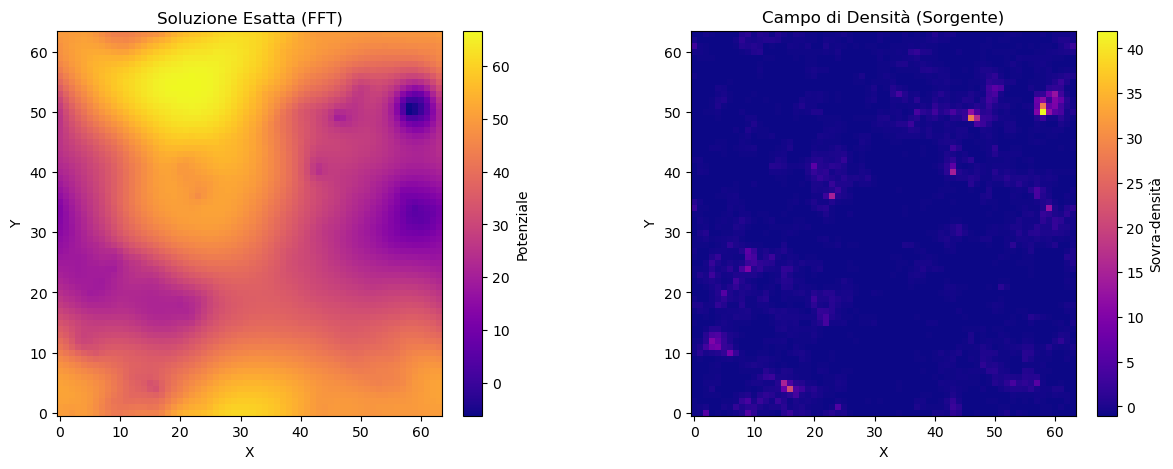

In [18]:
fig, axs = plt.subplots(1, 2, figsize=(15, 5))
axs[0].imshow(v_true[:, :, N//2], origin='lower', cmap='plasma')
axs[0].set_title("Soluzione Esatta (FFT)")
axs[1].imshow(f_density[:, :, N//2], origin='lower', cmap='plasma')
axs[1].set_title("Campo di Densità (Sorgente)")

for ax in axs:
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
fig.colorbar(axs[0].images[0], ax=axs[0], fraction=0.046, pad=0.04, label='Potenziale')
fig.colorbar(axs[1].images[0], ax=axs[1], fraction=0.046, pad=0.04, label='Sovra-densità')
plt.show()

In [19]:

# 3. Risolvi con JACOBI (Il tuo codice)
print("3. Esecuzione Jacobi Solver...")
v_jacobi = np.zeros_like(f_density) # Partiamo da zero
jac_buffer = np.zeros_like(f_density)

n_iter = 200 # Jacobi è lento sulle grandi scale, serve pazienza

# Parametri per la tua funzione
nmesh_dims = np.array([N, N, N], dtype=np.int32)
beta = 0.0      # Disattiviamo RSD per confrontare con Poisson puro
damping = 0.66
los = np.array([0.,0.,1.])

# Loop di iterazione
for i in range(n_iter):
    jacobi_jit(
        v=v_jacobi.ravel(),
        f=f_density.ravel(),
        jac_buffer=jac_buffer.ravel(),
        nmesh_dims=nmesh_dims,
        localnmeshx=N,
        offsetx=0,
        boxsize=boxsize,
        boxcenter=boxcenter,
        beta=beta,
        damping_factor=damping,
        los_vector=los,
        use_plane_parallel=True
    )
    if (i % 10) == 0:
        err = np.std(v_jacobi - v_true)
        print(f"   Iter {i}: Errore  = {err:.5f}")


3. Esecuzione Jacobi Solver...
   Iter 0: Errore  = 49.74369
   Iter 10: Errore  = 48.63139
   Iter 20: Errore  = 47.61789
   Iter 30: Errore  = 46.66898
   Iter 40: Errore  = 45.77034
   Iter 50: Errore  = 44.91344
   Iter 60: Errore  = 44.09245
   Iter 70: Errore  = 43.30313
   Iter 80: Errore  = 42.54220
   Iter 90: Errore  = 41.80707
   Iter 100: Errore  = 41.09560
   Iter 110: Errore  = 40.40602
   Iter 120: Errore  = 39.73681
   Iter 130: Errore  = 39.08669
   Iter 140: Errore  = 38.45450
   Iter 150: Errore  = 37.83925
   Iter 160: Errore  = 37.24003
   Iter 170: Errore  = 36.65604
   Iter 180: Errore  = 36.08655
   Iter 190: Errore  = 35.53090


4. Visualizzazione...


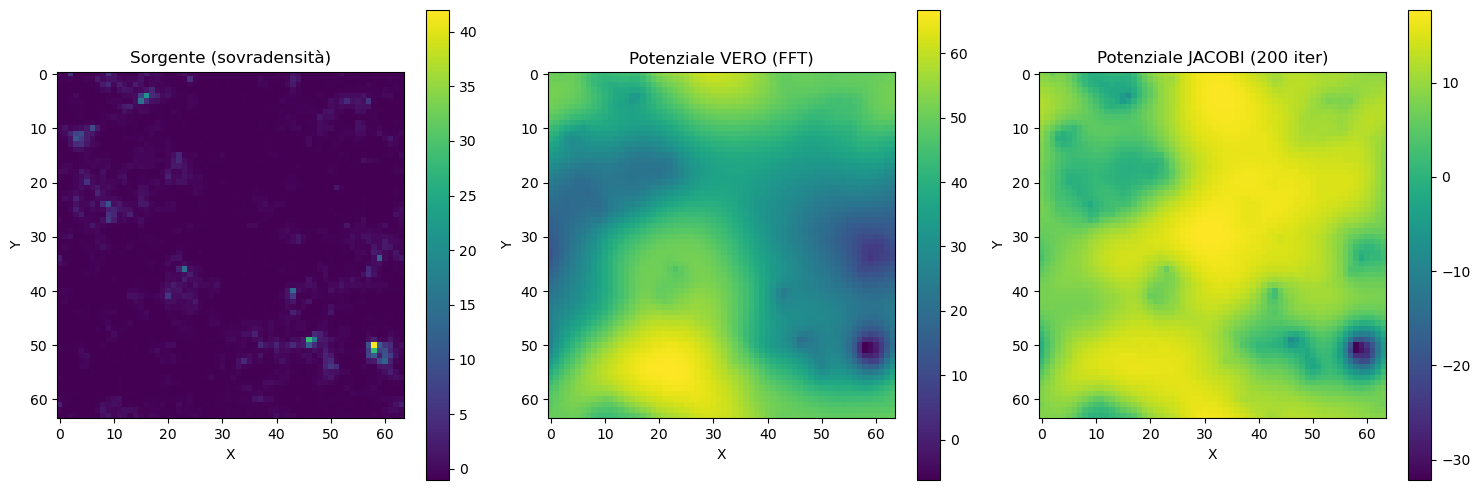

In [20]:
# 4. Confronto Visivo
print("4. Visualizzazione...")

# Prendiamo una fetta centrale (z = N/2)
slice_idx = N // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot Densità
im0 = axes[0].imshow(f_density[:, :, slice_idx], cmap='viridis')
axes[0].set_title("Sorgente (sovradensità)")
plt.colorbar(im0, ax=axes[0])

# Plot Soluzione Vera
im1 = axes[1].imshow(v_true[:, :, slice_idx], cmap='viridis')
axes[1].set_title("Potenziale VERO (FFT)")
plt.colorbar(im1, ax=axes[1])

# Plot Soluzione Jacobi
im2 = axes[2].imshow(v_jacobi[:, :, slice_idx], cmap='viridis')
axes[2].set_title(f"Potenziale JACOBI ({n_iter} iter)")
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xlabel("X")
    ax.set_ylabel("Y")

plt.tight_layout()
plt.show()

In [21]:
# Calcolo correlazione
corr = np.corrcoef(v_true.ravel(), v_jacobi.ravel())[0, 1]
print(f"\nCorrelazione tra soluzione Vera e Jacobi: {corr:.4f} (1.0 = Perfetto)")


Correlazione tra soluzione Vera e Jacobi: 0.8795 (1.0 = Perfetto)


# Check residual

In [22]:
from zeldareco.displacement_solver.multigrid_lib import residual_jit

In [23]:
# Parametri standard
N = 64
boxcenter = boxsize / 2.0
nmesh_dims = np.array([N, N, N], dtype=np.int64)
localnmeshx = N
offsetx = 0
beta = 0.0 # Niente RSD per ora
los = np.array([0., 0., 1.])

# Buffer vuoto per il risultato
res_out = np.zeros(N*N*N, dtype=np.float64)

Test: Se il potenziale v è zero ovunque, il Laplaciano è zero. Il residuo in uscita deve essere identico bit-per-bit alla sorgente in ingresso.

In [24]:
def test_identity():
    print("\n--- TEST 1: Identità (v=0) ---")
    
    # Input
    v = np.zeros(N*N*N) # Potenziale nullo
    f = np.random.rand(N*N*N) # Sorgente casuale
    
    # Eseguiamo
    residual_jit(v, f, res_out, nmesh_dims, localnmeshx, offsetx, boxsize, boxcenter, beta, los, True)
    
    # Verifica
    # Deve essere esattamente uguale a f
    diff = np.max(np.abs(res_out - f))
    
    print(f"Differenza Max tra Output e Input f: {diff:.6e}")
    if diff < 1e-15:
        print("[PASS] Con v=0, il residuo è uguale alla sorgente.")
    else:
        print("[FAIL] C'è qualcosa che non va. Dovrebbe restituire f.")

test_identity()


--- TEST 1: Identità (v=0) ---
Differenza Max tra Output e Input f: 0.000000e+00
[PASS] Con v=0, il residuo è uguale alla sorgente.


La derivata di una costante è zero. Se v=100.0 ovunque e f=0: il residuo deve essere zero.

In [25]:
def test_flat():
    print("\n--- TEST 2: Campo Piatto (v=const) ---")
    
    # Input
    v = np.ones(N*N*N) * 100.0 # Potenziale costante
    f = np.zeros(N*N*N)        # Sorgente nulla
    
    # Eseguiamo
    residual_jit(v, f, res_out, nmesh_dims, localnmeshx, offsetx, boxsize, boxcenter, beta, los, True)
    
    # Verifica
    max_val = np.max(np.abs(res_out))
    
    print(f"Valore Max del residuo (Atteso ~0): {max_val:.6e}")
    if max_val < 1e-12:
        print("[PASS] La derivata di una costante è zero.")
    else:
        print("[FAIL] Il Laplaciano di una costante non è venuto zero!")

test_flat()


--- TEST 2: Campo Piatto (v=const) ---
Valore Max del residuo (Atteso ~0): 0.000000e+00
[PASS] La derivata di una costante è zero.


Test 3: Il Test "Matematico" (Cancellazione Esatta)

Logica: Questo è il test definitivo.

Creiamo un potenziale v casuale.

Calcoliamo il suo Laplaciano $\nabla^2v$ usando numpy.roll (che simula i vicini esattamente come fa il tuo codice JIT).

Impostiamo f esattamente uguale a questo Laplaciano.

Allora $r=\nabla^2v-\nabla^2v$.

Se questo passa, la tua funzione residual_jit è geometricamente perfetta.

In [26]:
def test_exact_cancellation():
    print("\n--- TEST 3: Cancellazione Esatta (Math Check) ---")
    
    # 1. Creiamo v random
    v_3d = np.random.rand(N, N, N)
    
    # 2. Calcoliamo il Laplaciano Discreto manualmente con Numpy
    #    Laplacian = (v[i+1] + v[i-1] + ... - 6*v[i]) / dx^2
    cellsize = boxsize[0] / N
    icellsize2 = 1.0 / (cellsize**2)
    
    # Somma dei vicini usando roll (periodico)
    term_x = (np.roll(v_3d, -1, axis=0) + np.roll(v_3d, 1, axis=0))
    term_y = (np.roll(v_3d, -1, axis=1) + np.roll(v_3d, 1, axis=1))
    term_z = (np.roll(v_3d, -1, axis=2) + np.roll(v_3d, 1, axis=2))
    
    laplacian_numpy = (term_x + term_y + term_z - 6.0*v_3d) * icellsize2
    
    # 3. Impostiamo f uguale a questo Laplaciano
    f_input = laplacian_numpy.ravel()
    v_input = v_3d.ravel()
    
    # 4. Eseguiamo residual_jit
    #    Dovrebbe calcolare: r = f - Laplacian(v)
    #    Quindi: r = Laplacian_numpy - Laplacian_jit
    residual_jit(v_input, f_input, res_out, nmesh_dims, localnmeshx, offsetx, boxsize, boxcenter, beta, los, True)
    
    # 5. Verifica
    err = np.max(np.abs(res_out))
    print(f"Errore residuo (Atteso ~0): {err:.6e}")
    
    if err < 1e-10:
        print("[PASS] La funzione residual_jit calcola ESATTAMENTE f - Nabla^2(v).")
    else:
        print("[FAIL] C'è una discrepanza tra il calcolo Numpy e JIT.")
        print("Probabile errore: gestione indici o fattore dx^2 mancante.")

test_exact_cancellation()


--- TEST 3: Cancellazione Esatta (Math Check) ---
Errore residuo (Atteso ~0): 1.110223e-15
[PASS] La funzione residual_jit calcola ESATTAMENTE f - Nabla^2(v).


# Test multigrid solver

In [27]:
from zeldareco.displacement_solver.multigrid import MultigridSolver
from zeldareco.utils import mock_generator

In [28]:
boxsize_new = 1280
cell_size = 10
N_new = boxsize_new // cell_size
new_density = mock_generator.generate_lognormal_map(pk_interp, side=boxsize_new, spacing=cell_size)
new_density = new_density - np.mean(new_density)

mean of G_x is =  9.147955830346444e-19
variance of G_x is =  0.788626720066123


In [29]:
new_density.shape

(128, 128, 128)

In [30]:
type(N_new)

int

In [31]:
boxsize_array = np.array([float(boxsize_new)]*3)

In [32]:
# 2. Risolvi
solver = MultigridSolver(N_new, boxsize_new, use_plane_parallel=True)

2026-03-04 14:43:59,724 - zeldareco.displacement_solver.multigrid - INFO - Solver Init: 128 -> 4


Solve with vcycles

In [33]:
# solve with v cycles
v_mg = solver.solve(new_density, beta=0.0, los=los, n_cycles=10)

Starting V-Cycles (N=10, Smooth=5, Damp=0.4)...
  Cycle 0: Res 1.2902e-01
  Cycle 5: Res 6.8248e-05


In [34]:

# 3. Verifica
print("\nVerifica vs FFT...")
v_true = solve_poisson_fft(new_density, boxsize_array[0])

mask = (v_true != 0.0)
# Rimuovi medie per confronto
diff = np.zeros_like(v_true)
diff[mask] = (v_mg[mask] - v_true[mask])/v_true[mask]
print(f"Errore StdDev: {np.std(diff):.6e}")


Verifica vs FFT...
Errore StdDev: 1.713009e+01


In [35]:
slice = N // 4

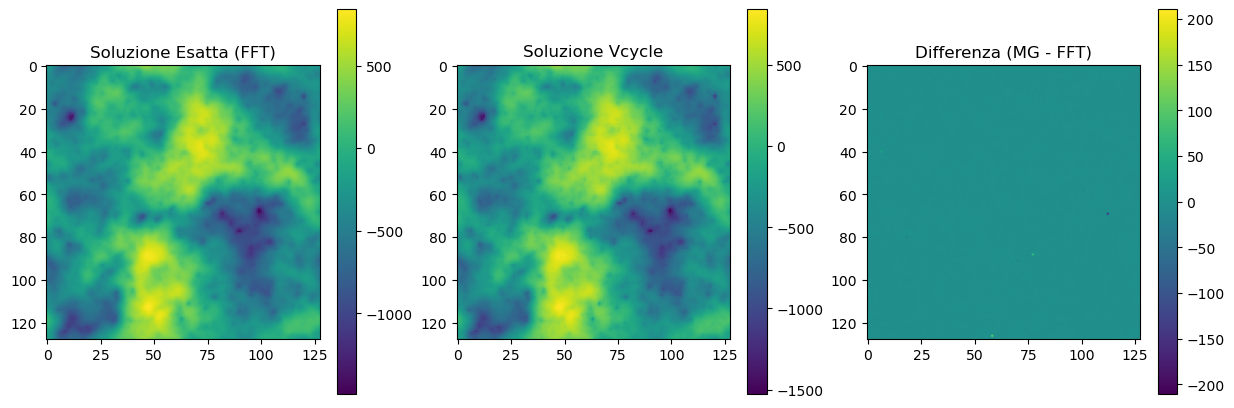

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
im0 = axes[0].imshow(v_true[:, :, slice], cmap='viridis')
axes[0].set_title("Soluzione Esatta (FFT)")
plt.colorbar(im0, ax=axes[0])
im1 = axes[1].imshow(v_mg[:, :, slice], cmap='viridis')
axes[1].set_title("Soluzione Vcycle")
plt.colorbar(im1, ax=axes[1])

from matplotlib.colors import TwoSlopeNorm
# Usa una normalizzazione diverging centrata su 0 per evidenziare le differenze
norm = TwoSlopeNorm(vmin=-np.max(np.abs(diff)[:, :, slice]),
                    vcenter=0, vmax=np.max(np.abs(diff)[:, :, slice]))

im2 = axes[2].imshow(diff[:, :, N//2], cmap='viridis', norm=norm)
axes[2].set_title("Differenza (MG - FFT)")
plt.colorbar(im2, ax=axes[2], )

Solve with full multigrid

In [37]:
v_fmg = solver.solve_fmg(new_density, beta=0.8, los=los)

2026-03-04 14:44:02,840 - zeldareco.displacement_solver.multigrid - INFO - Starting FMG (Cycles=6, Smooth=5, Damp=0.4)...


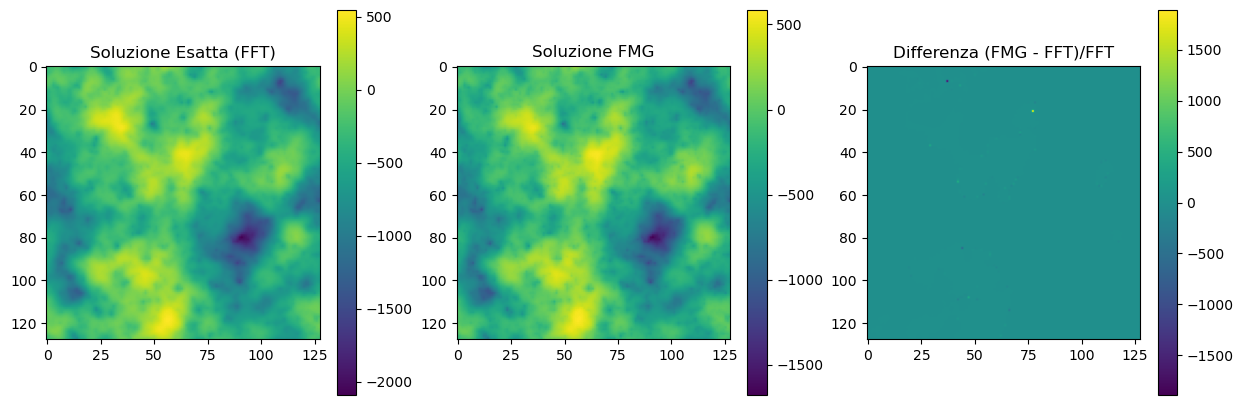

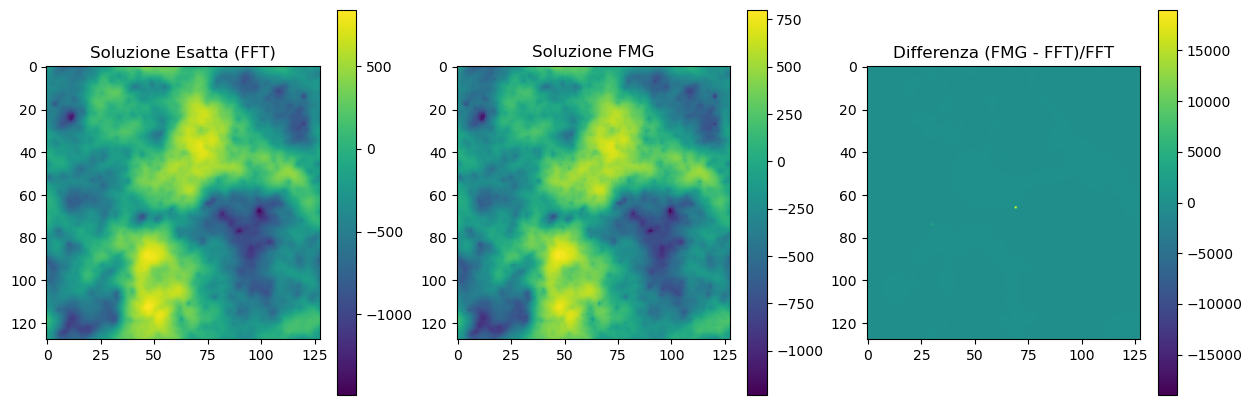

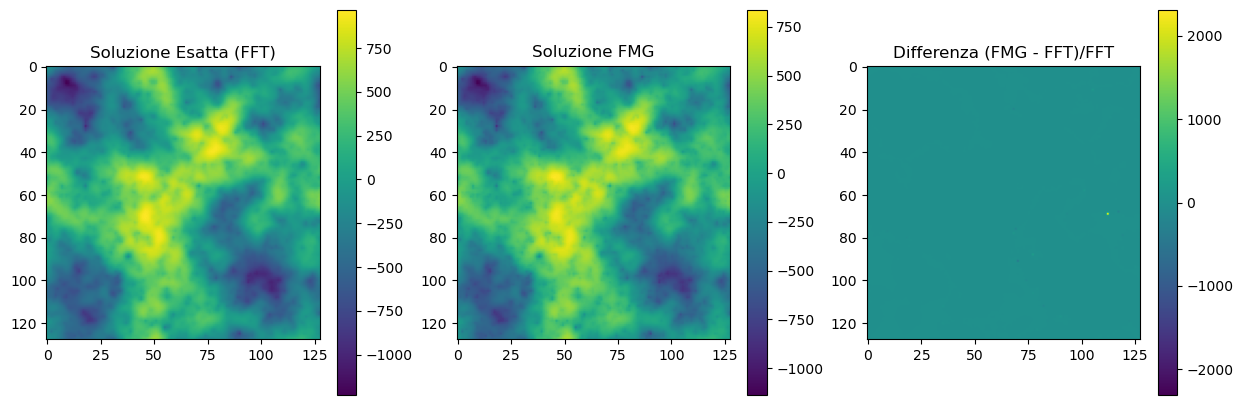

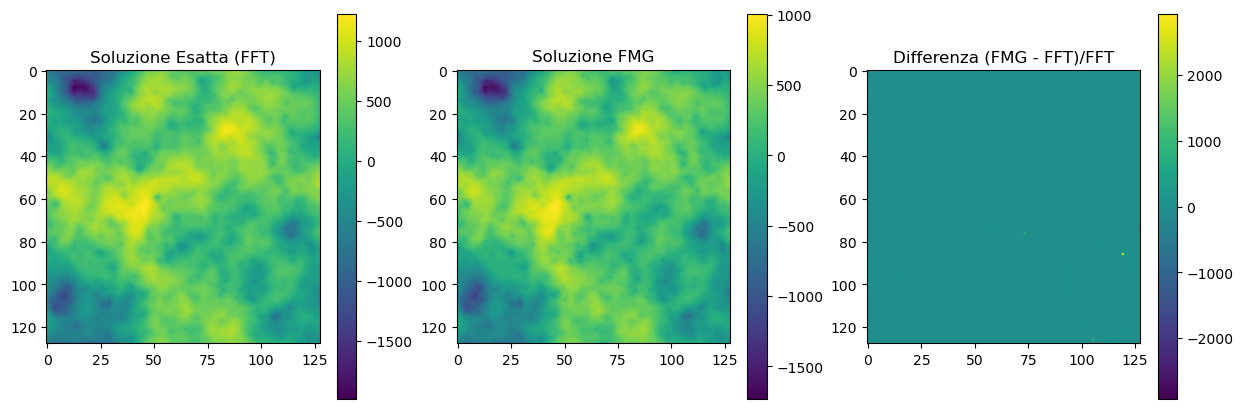

In [38]:
for slice in range(0, N, N//4):

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    im0 = axes[0].imshow(v_true[:, :, slice], cmap='viridis')
    axes[0].set_title("Soluzione Esatta (FFT)")
    plt.colorbar(im0, ax=axes[0])

    im1 = axes[1].imshow(v_fmg[:, :, slice], cmap='viridis')
    axes[1].set_title("Soluzione FMG")
    plt.colorbar(im1, ax=axes[1])
    diff_fmg = (v_fmg - v_true)/v_true

    norm_fmg = TwoSlopeNorm(vmin=-np.max(np.abs(diff_fmg[:, :, slice])), 
                            vcenter=0, vmax=np.max(np.abs(diff_fmg[:, :, slice])))
    im2 = axes[2].imshow(diff_fmg[:, :, slice], cmap='viridis', norm=norm_fmg)
    axes[2].set_title("Differenza (FMG - FFT)/FFT")
    plt.colorbar(im2, ax=axes[2])

2026-03-04 14:44:05,783 - zeldareco.displacement_solver.multigrid - INFO - Solver Init: 64 -> 4



--- TEST V-CYCLE ---
Starting V-Cycles (N=10, Smooth=5, Damp=0.4)...
  Cycle 0: Res 2.3674e-01
  Cycle 5: Res 3.4407e-04


2026-03-04 14:44:06,730 - zeldareco.displacement_solver.multigrid - INFO - Starting FMG (Cycles=1, Smooth=5, Damp=0.4)...



--- TEST FMG ---

Ampiezza Sorgente: 1.000
Ampiezza V-Cycle : 252.537


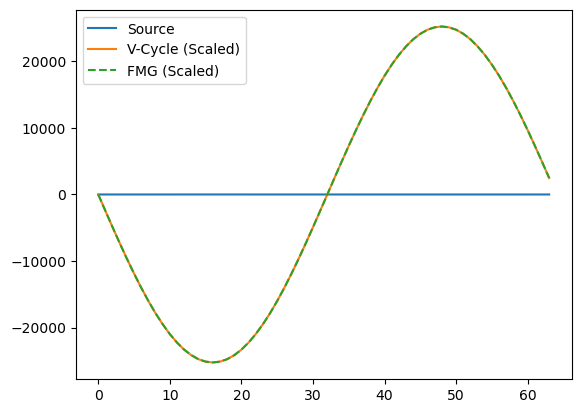

In [39]:
def run_test():
    N = 64
    L = 100.0
    boxsize = np.array([L, L, L])
    
    # Onda Sinusoidale
    x = np.linspace(0, L, N, endpoint=False)
    X, Y, Z = np.meshgrid(x, x, x, indexing='ij')
    k = 2 * np.pi / L
    source = np.sin(k * X)
    source -= np.mean(source) # FONDAMENTALE!
    
    # Init Solver
    solver = MultigridSolver(N, boxsize)
    
    # TEST 1: V-CYCLE
    print("\n--- TEST V-CYCLE ---")
    v_mg = solver.solve(source, n_cycles=10)
    
    # TEST 2: FMG
    print("\n--- TEST FMG ---")
    v_fmg = solver.solve_fmg(source, v_cycles=1)
    
    # Analitica (approx 1D)
    # v = -source / k^2 (ma le costanti geometriche interne possono scalare tutto)
    # Controlliamo solo coerenza FFT
    amp_source = (source.max() - source.min())/2
    amp_v = (v_mg.max() - v_mg.min())/2
    
    print(f"\nAmpiezza Sorgente: {amp_source:.3f}")
    print(f"Ampiezza V-Cycle : {amp_v:.3f}")
    
    # Plot
    plt.plot(source[:,0,0], label='Source')
    plt.plot(v_mg[:,0,0]*100, label='V-Cycle (Scaled)') # Scalato solo per vedere forma
    plt.plot(v_fmg[:,0,0]*100, '--', label='FMG (Scaled)')
    plt.legend()
    plt.show()

if __name__ == "__main__":
    run_test()

# Test potential interpolation to displacement

In [40]:
pos = mock_generator.poisson_sample_from_map(new_density, side=boxsize_new, spacing=cell_size, N_objects=100000)

total number of objects =  100226 out of  100000


In [52]:
shifts = np.zeros((len(pos), 3), dtype=np.float64)

In [53]:
from zeldareco.displacement_solver.multigrid_lib import interpolate_displacement_jit

In [54]:
boxsize_new

1280

In [55]:
interpolate_displacement_jit(v_fmg, pos, shifts,  np.array([128, 128, 128], dtype=int), 0, np.array([boxsize_new]*3))

In [57]:
shifts.shape

(100226, 3)

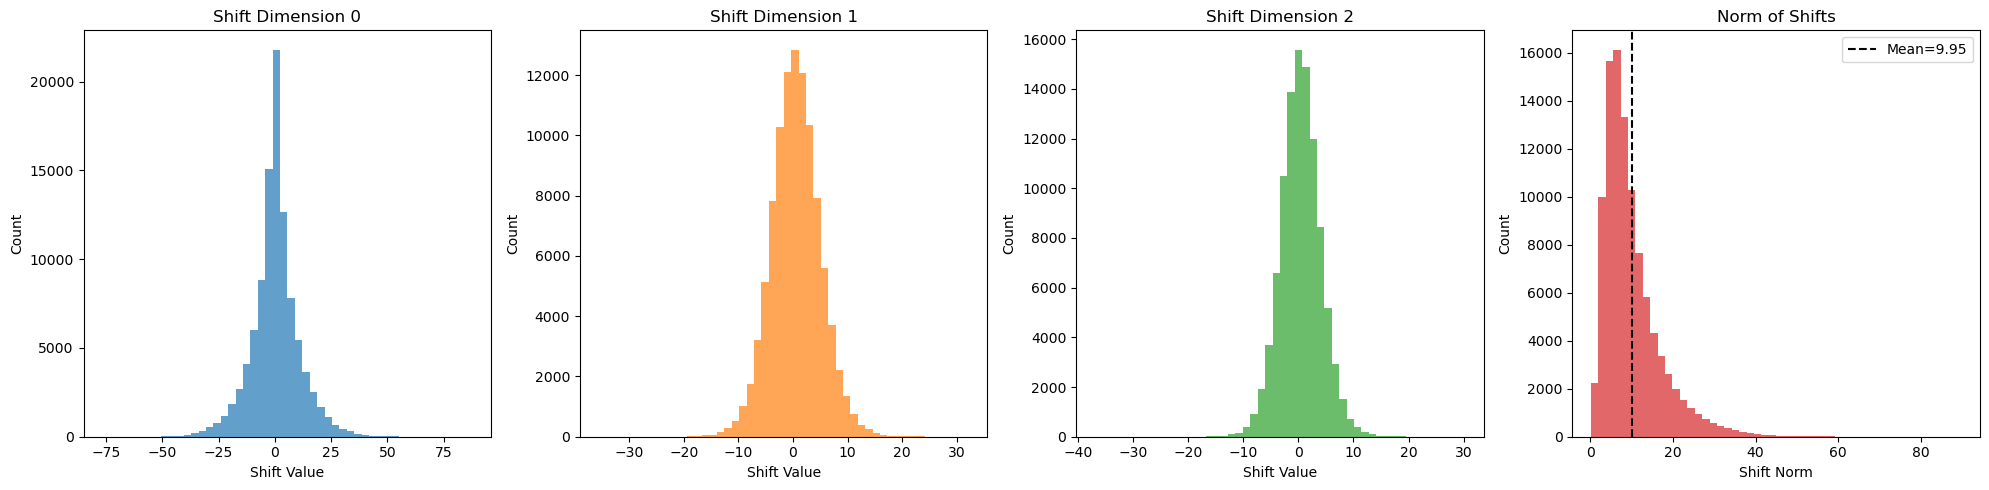

In [64]:
fig, axs = plt.subplots(1, 4, figsize=(20, 5))

for i in range(3):
    axs[i].hist(shifts[:, i], bins=50, color='C'+str(i), alpha=0.7)
    axs[i].set_title(f"Shift Dimension {i}")
    axs[i].set_xlabel("Shift Value")
    axs[i].set_ylabel("Count")

axs[3].hist(np.linalg.norm(shifts, axis=1), bins=50, color='C3', alpha=0.7)
axs[3].axvline(np.mean(np.linalg.norm(shifts, axis=1)), color='k', linestyle='--', label='Mean={:.2f}'.format(np.mean(np.linalg.norm(shifts, axis=1))))
axs[3].set_title("Norm of Shifts")
axs[3].set_xlabel("Shift Norm")
axs[3].set_ylabel("Count")


axs[3].legend()
plt.tight_layout()

# Test plane_parallel==false

This is only a technical test, to check the code runs. The output shall be tested by comparing this code with another MG code.

In [65]:
solver_los = MultigridSolver(N_new, boxsize_new, use_plane_parallel=False)

2026-03-04 15:12:11,061 - zeldareco.displacement_solver.multigrid - INFO - Solver Init: 128 -> 4


In [66]:
v_fmg = solver_los.solve_fmg(new_density, beta=0.8, los=los)

2026-03-04 15:12:51,834 - zeldareco.displacement_solver.multigrid - INFO - Starting FMG (Cycles=6, Smooth=5, Damp=0.4)...
